In [1]:
# Importing Modules
import torch
import random
import numpy as np
import pandas as pd
from src.dataloader import loadData
from src.model import GNNModel
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.data import Data
from IPython.display import Image

In [2]:
# Function to set seed
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [3]:
# Wrapper model
class WrappedModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x, edge_index, batch=None, **kwargs):
        edge_attr = kwargs.get("edge_attr", None)
        data = Data(x=x, edge_index=edge_index, batch=batch, edge_attr=edge_attr)
        data = data.to(next(self.model.parameters()).device)
        out = self.model(data)
        return out[0] if isinstance(out, tuple) else out

In [4]:
# Function to plot explaination
def plot_molecule_explanation(smiles, explanation, threshold=0.5):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return

    node_importance = explanation.node_mask.sum(dim=1) if explanation.node_mask.dim() > 1 else explanation.node_mask
    edge_importance = explanation.edge_mask
    
    node_importance = (node_importance - node_importance.min()) / (node_importance.max() - node_importance.min() + 1e-6)
    edge_importance = (edge_importance - edge_importance.min()) / (edge_importance.max() - edge_importance.min() + 1e-6)

    highlight_atoms = [i for i, val in enumerate(node_importance) if val > threshold]
    
    highlight_bonds = []
    edge_index = explanation.edge_index
    for i in range(edge_index.shape[1]):
        if edge_importance[i] > threshold:
            u, v = edge_index[0, i].item(), edge_index[1, i].item()
            bond = mol.GetBondBetweenAtoms(u, v)
            if bond:
                highlight_bonds.append(bond.GetIdx())

    for atom in mol.GetAtoms():
        atom.SetProp("atomLabel", atom.GetSymbol())

    d2d = rdMolDraw2D.MolDraw2DCairo(500, 500)
    opts = d2d.drawOptions()
    
    opts.addAtomIndices = False
    opts.prepareMolsBeforeDrawing = True

    rdMolDraw2D.PrepareAndDrawMolecule(
        d2d, 
        mol, 
        highlightAtoms=highlight_atoms, 
        highlightBonds=highlight_bonds
    )
    d2d.FinishDrawing()
    return Image(d2d.GetDrawingText())

In [5]:
# Function to run explanation
def RunAll(X, y, modelName, dataName):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    temp_df = pd.read_csv(f"results/Output_Hyperparameter_Optimization_GNN_{dataName}.csv")
    temp = temp_df[temp_df["Model"] == modelName]
    params = temp.sort_values(by=["RMSE"]).head(1)[["h_dim", "b_size", "lr", "d_out", "w_decay", "layers"]].to_dict('records')[0]
    model = torch.load(f"models/{modelName}_{dataName}.pth", weights_only=False).to(device)
    wrapped_model = WrappedModel(model).to(device)
    explainer = Explainer(
        model=wrapped_model,
        algorithm=GNNExplainer(epochs=1000),
        explanation_type="model",
        node_mask_type="attributes",
        edge_mask_type="object",
        model_config=dict(mode="regression", task_level="graph", return_type="raw"),
    )

    test_loader = loadData(X, y, batch_size=1, shuf=False)

    for i, graph in enumerate(test_loader):
        graph = graph.to(device)
        explanation = explainer(x=graph.x, edge_index=graph.edge_index, batch=graph.batch)
    
        print(f"SMILES: {X[i]}")
        print(modelName)
        print(f"Prediction {dataName}: {explanation.prediction.item():.4f} (Actual: {y[i]})")
    
        img = plot_molecule_explanation(X[i], explanation, threshold=0.7)
        display(img) 
    
        break

SMILES: C=CC(C)C
GraphSAGE
Prediction ESOL: -3.1358 (Actual: -2.73)


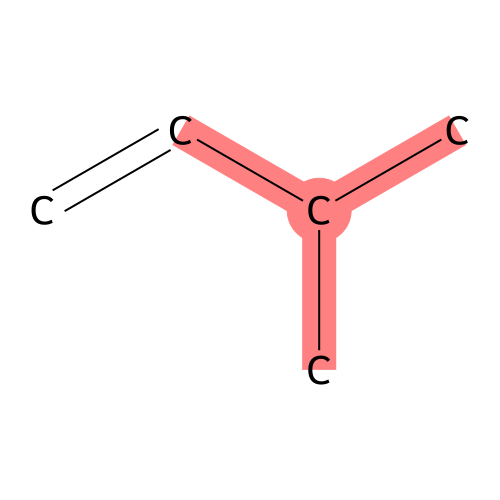

SMILES: C=CC(C)C
GCN
Prediction FreeSolv: -3.8594 (Actual: 1.83)


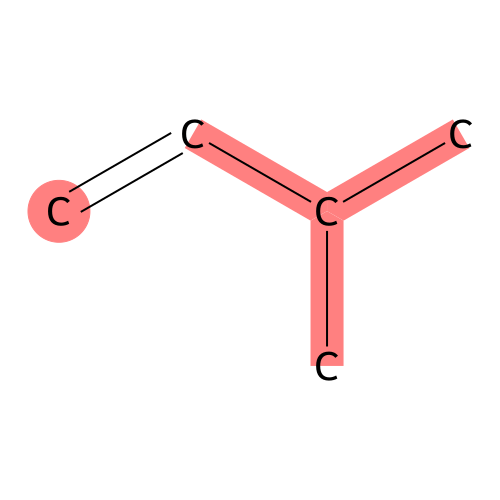

SMILES: CCCC(C)=O
GraphSAGE
Prediction ESOL: -2.9939 (Actual: -0.19)


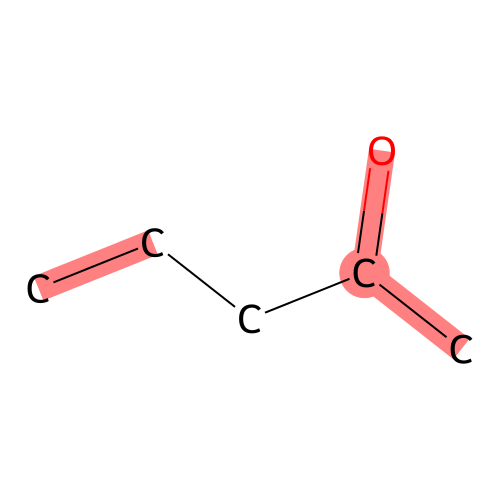

SMILES: CCCC(C)=O
GCN
Prediction FreeSolv: -4.1290 (Actual: -3.52)


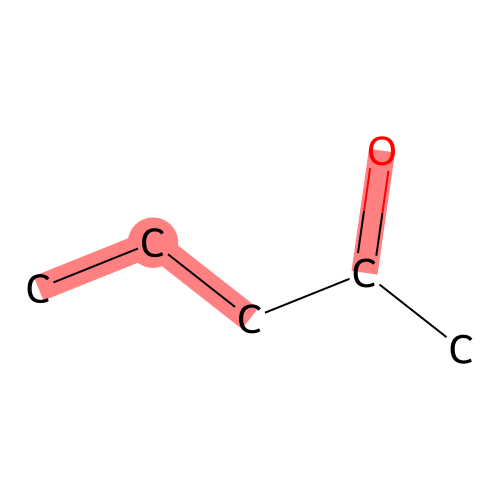

SMILES: Nc1cccc(Cl)c1
GraphSAGE
Prediction ESOL: -3.3858 (Actual: -1.37)


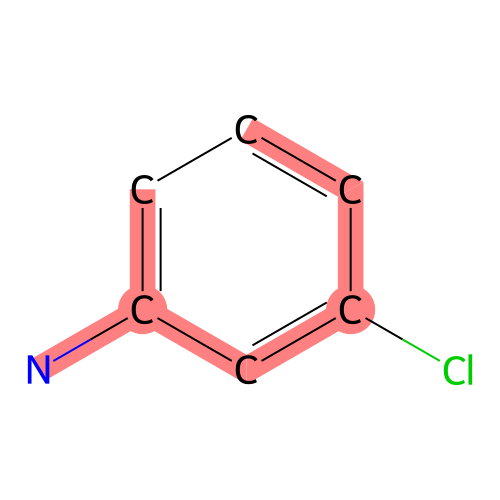

SMILES: Nc1cccc(Cl)c1
GCN
Prediction FreeSolv: -4.7309 (Actual: -5.82)


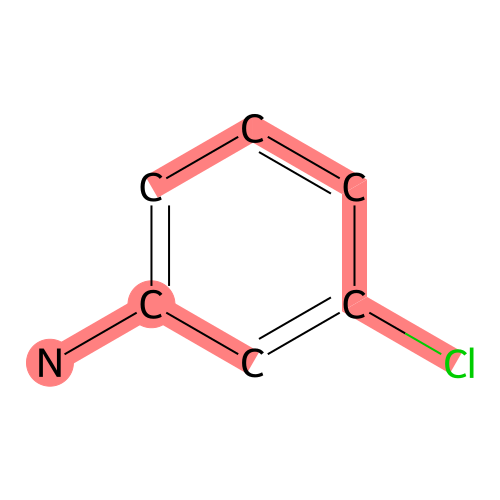

SMILES: CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2
GCN
Prediction B3DB: -0.4943 (Actual: -0.06)


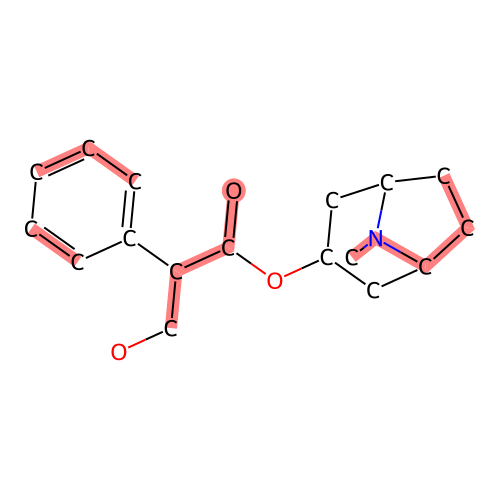

SMILES: CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2
GraphSAGE
Prediction Lipophilicity: 2.5438 (Actual: -0.09)


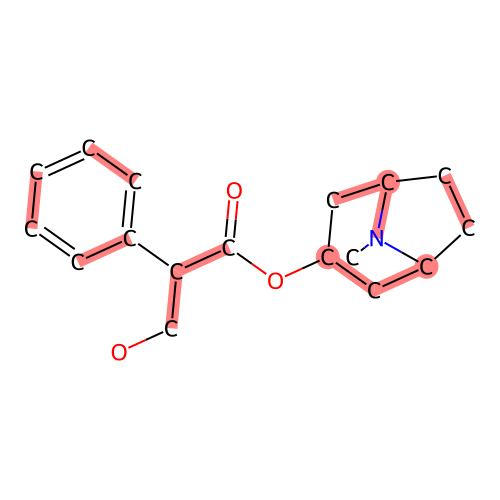

SMILES: NC(=O)N1c2ccccc2C=Cc2ccccc21
GCN
Prediction B3DB: -0.4484 (Actual: -0.1)


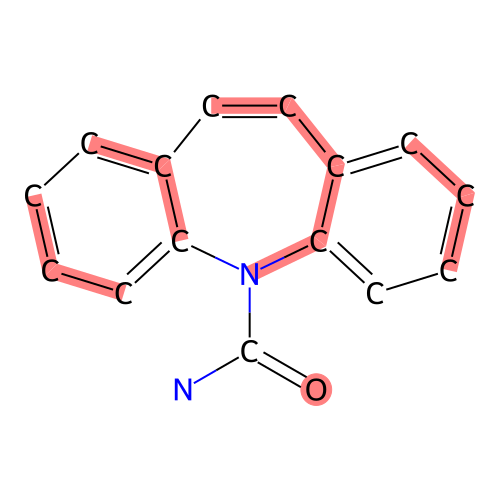

SMILES: NC(=O)N1c2ccccc2C=Cc2ccccc21
GraphSAGE
Prediction Lipophilicity: 2.2548 (Actual: 1.65)


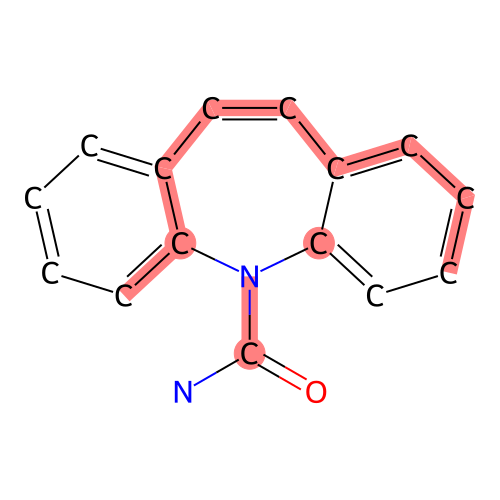

SMILES: COc1cccc2c(O)c3c(c(O)c12)C(=O)C1=C(CC(O)(C(=O)CO)CC1OC1CC(N)C(O)C(C)O1)C3=O
GCN
Prediction B3DB: -0.5856 (Actual: -0.83)


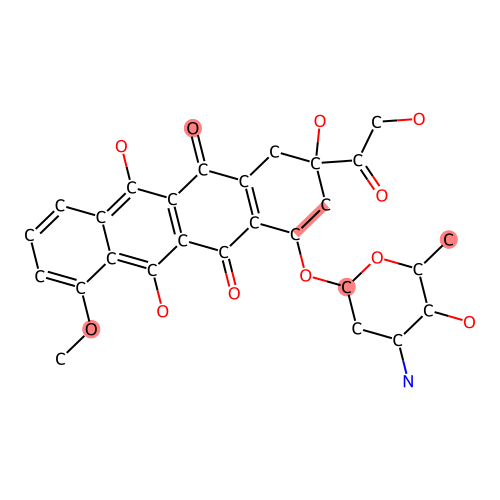

SMILES: COc1cccc2c(O)c3c(c(O)c12)C(=O)C1=C(CC(O)(C(=O)CO)CC1OC1CC(N)C(O)C(C)O1)C3=O
GraphSAGE
Prediction RT: 228.6112 (Actual: 361.01904)


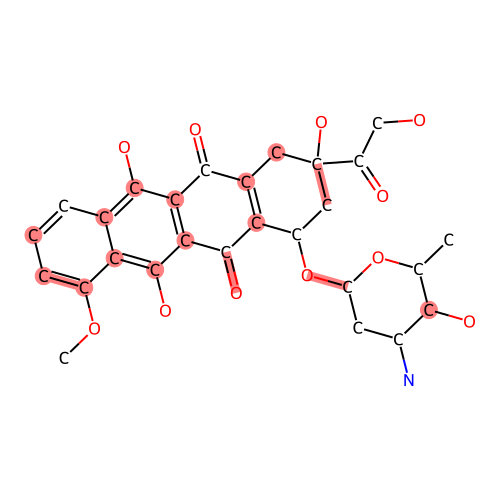

SMILES: Nc1nc2ccc(OC(F)(F)F)cc2s1
GraphSAGE
Prediction Lipophilicity: 2.5619 (Actual: 3.34)


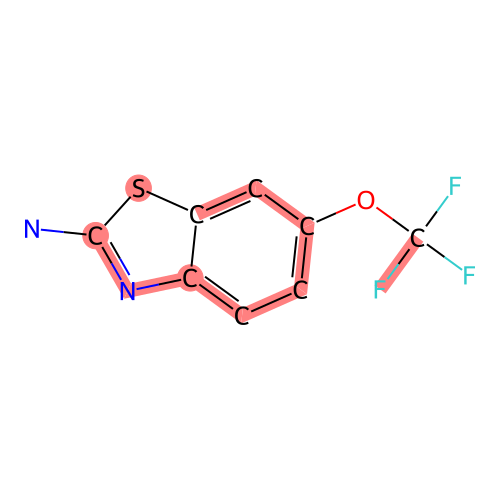

SMILES: Nc1nc2ccc(OC(F)(F)F)cc2s1
GraphSAGE
Prediction RT: 219.4379 (Actual: 61.82802)


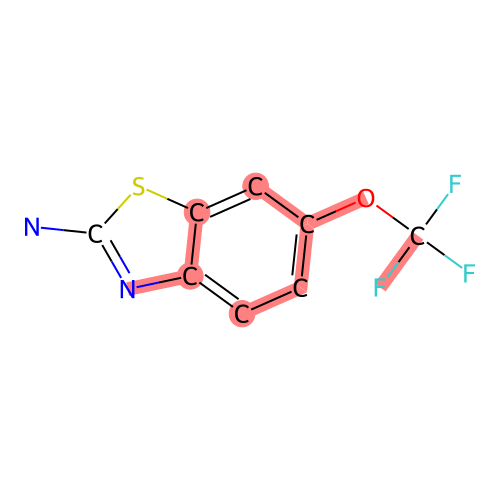

In [6]:
# Case study data
data = pd.read_csv("data/case_study_data.csv")

# Run for all case studies
for i in range(len(data)):
    temp = data.iloc[i]
    X = [temp["smiles"]]
    y1 = [temp["target1"]]
    y2 = [temp["target2"]]
    dataName1 = temp["data1"]
    dataName2 = temp["data2"]
    modelName1 = temp["model1"]
    modelName2 = temp["model2"]
    RunAll(X, y1, modelName1, dataName1)
    RunAll(X, y2, modelName2, dataName2)
         